In [ ]:
import kagglehub
dataset_path = kagglehub.dataset_download("salader/dogs-vs-cats")

100%|██████████| 1.06G/1.06G [00:48<00:00, 23.5MB/s]

Extracting files...


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv1D,Conv2D,Flatten,Dense,MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization, Dropout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, r2_score
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.datasets.mnist import load_data
from keras.datasets.fashion_mnist import load_data
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [ ]:
!ln -s $dataset_path"/train" "/content/"
!ln -s $dataset_path"/test" "/content/"

In [ ]:
train_ds=keras.utils.image_dataset_from_directory(
    directory="/content/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)
validation_ds=keras.utils.image_dataset_from_directory(
    directory="/content/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)
def normalize_process(image,label):
  image=tf.cast(image/255.,tf.float32)
  return image, label
train_ds=train_ds.map(normalize_process)
validation_ds=validation_ds.map(normalize_process)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


# AlexNet

In [ ]:
amodel = Sequential()
amodel.add(Conv2D(96, kernel_size=(11, 11), strides=4, padding="valid", activation="relu", input_shape=(256, 256, 3)))
amodel.add(BatchNormalization())
amodel.add(MaxPooling2D(pool_size=(3, 3), strides=2))
amodel.add(Conv2D(256, kernel_size=(5, 5), padding="same", activation="relu"))
amodel.add(BatchNormalization())
amodel.add(MaxPooling2D(pool_size=(3, 3), strides=2))
amodel.add(Conv2D(384, kernel_size=(3, 3), padding="same", activation="relu"))
amodel.add(BatchNormalization())
amodel.add(Conv2D(384, kernel_size=(3, 3), padding="same", activation="relu"))
amodel.add(BatchNormalization())
amodel.add(Conv2D(256, kernel_size=(3, 3), padding="same", activation="relu"))
amodel.add(BatchNormalization())
amodel.add(MaxPooling2D(pool_size=(3, 3), strides=2))
amodel.add(Flatten())
amodel.add(Dense(4096, activation="relu"))
amodel.add(Dropout(0.5))
amodel.add(Dense(4096, activation="relu"))
amodel.add(Dropout(0.5))
amodel.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
amodel.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 62, 62, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 62, 62, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 30, 30, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 30, 30, 256)         │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 30, 30, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 14, 14, 384)         │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 14, 14, 384)         │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 14, 14, 384)         │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 14, 14, 384)         │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 14, 14, 256)         │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 14, 14, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4096)                │      37,752,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │           4,0

 Total params: 58,290,945 (222.36 MB)

 Trainable params: 58,288,193 (222.35 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
amodel.compile(optimizer="adam", metrics=["accuracy"], loss="binary_crossentropy")

In [ ]:
ahistory=amodel.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 80ms/step - accuracy: 0.5685 - loss: 3.3783 - val_accuracy: 0.6384 - val_loss: 0.6544
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.6229 - loss: 0.6868 - val_accuracy: 0.5468 - val_loss: 0.7084
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.6609 - loss: 0.6610 - val_accuracy: 0.6902 - val_loss: 0.5861
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.6810 - loss: 0.6362 - val_accuracy: 0.6652 - val_loss: 0.5943
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.7409 - loss: 0.5437 - val_accuracy: 0.5350 - val_loss: 1.0116
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.7751 - loss: 0.4988 - val_accuracy: 0.7570 - val_loss: 0.5431
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 77ms/step - accuracy: 0.8095 - loss: 0.4311 - val_accuracy: 0.7566 - val_loss: 0.5643
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 86ms/step - accuracy: 0.8409 - loss: 0.3819 - 

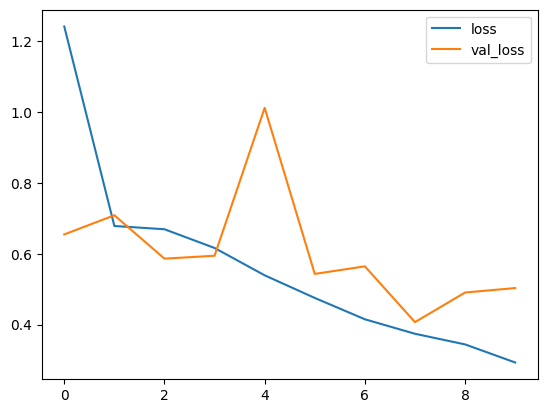

In [ ]:
plt.plot(ahistory.history["loss"], label="loss")
plt.plot(ahistory.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

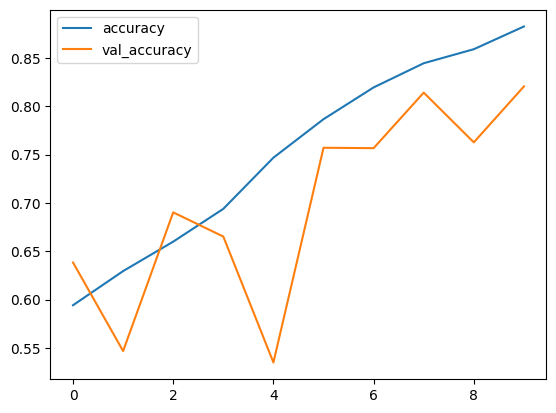

In [ ]:
plt.plot(ahistory.history["accuracy"], label="accuracy")
plt.plot(ahistory.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

In [ ]:
testimage=cv2.imread("/content/0881dfe7add91b44.jpg")

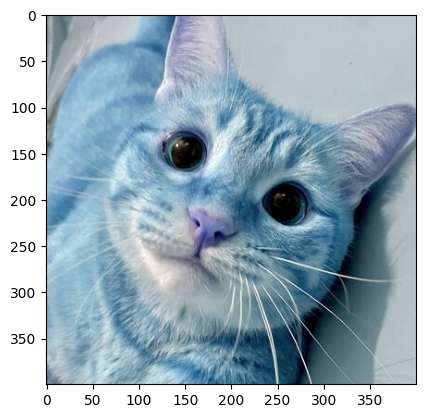

In [ ]:
plt.imshow(testimage)

In [ ]:
testimage.shape

(400, 400, 3)

In [ ]:
testimage = cv2.resize(testimage, (256, 256))

In [ ]:
testimage = testimage.reshape((1, 256, 256, 3))

In [ ]:
y_pred = amodel.predict(testimage)

NameError: name 'amodel' is not defined

In [ ]:
y_pred

array([[0.]], dtype=float32)

# GoogleNet

In [ ]:
gmodel = Sequential()

In [ ]:
gmodel.add(Conv2D(64, kernel_size=(7, 7), strides=2, padding="same", activation="relu", input_shape=(256, 256, 3)))
gmodel.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding="same"))
gmodel.add(Conv2D(64, kernel_size=(1, 1), strides=1, padding="same", activation="relu"))
gmodel.add(Conv2D(192, kernel_size=(3, 3), strides=1, padding="same", activation="relu"))
gmodel.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding="same"))
gmodel.add(Conv2D(64, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(128, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(Conv2D(128, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(192, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding="same"))
gmodel.add(Conv2D(192, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(208, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(Conv2D(160, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(224, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(Conv2D(128, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(256, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(Conv2D(112, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(288, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(Conv2D(256, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(320, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding="same"))
gmodel.add(Conv2D(256, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(320, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(Conv2D(384, kernel_size=(1, 1), padding="same", activation="relu"))
gmodel.add(Conv2D(384, kernel_size=(3, 3), padding="same", activation="relu"))
gmodel.add(Flatten())
gmodel.add(Dense(1024, activation="relu"))
gmodel.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
gmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 64)        │           9,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 192)         │         110,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 192)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 64)          │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 128)         │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 32, 32, 192)         │         221,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 192)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 192)         │          37,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 16, 16, 208)         │         359,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 16, 16, 160)         │          33,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 16, 16, 224)         │         322,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 16, 16, 128)         │          28,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 16, 16, 112)         │          28,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 16, 16, 288)         │         290,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 16, 16, 256)         │          73,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 16, 16, 320)         │         737,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 320)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 30,094,753 (114.80 MB)

 Trainable params: 30,094,753 (114.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gmodel.compile(optimizer="adam", metrics=["accuracy"], loss="binary_crossentropy")

In [ ]:
ghistory = gmodel.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 95ms/step - accuracy: 0.4997 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 94ms/step - accuracy: 0.5004 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.4993 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.5009 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.4959 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.5004 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 95ms/step - accuracy: 0.4998 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.5005 - loss: 0.6932 - 

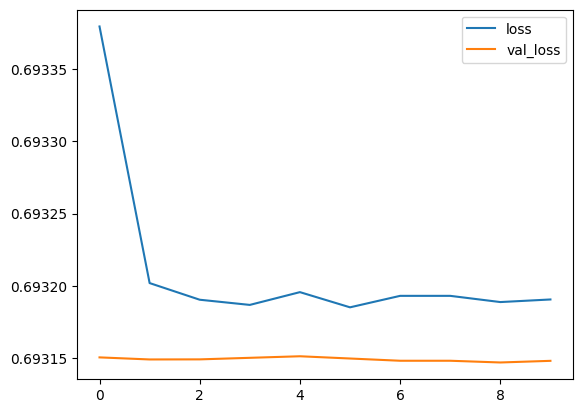

In [ ]:
plt.plot(ghistory.history["loss"], label="loss")
plt.plot(ghistory.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

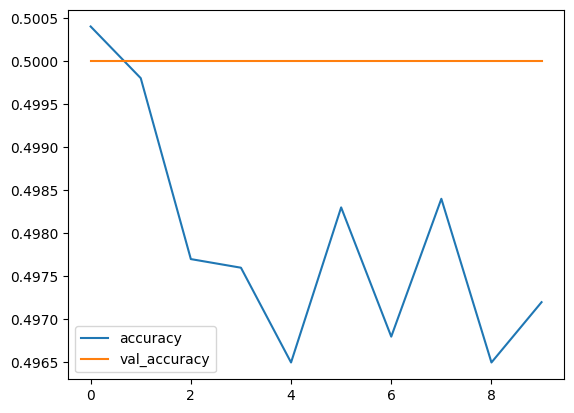

In [ ]:
plt.plot(ghistory.history["accuracy"], label="accuracy")
plt.plot(ghistory.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

In [ ]:
y_pred = gmodel.predict(testimage)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
y_pred

array([[0.49921563]], dtype=float32)